# 发表偏倚与稳健性:结论经得起推敲吗

meta 分析最尴尬的敌人不在数据里,而在**没进数据的那些研究里**。「阳性的、显著的小研究
更容易被写出来、被投出去、被接收」——这套选择机制叫**发表偏倚(publication bias)**,它
会系统性地把合并效应往**夸大**的方向推。样本越小、越依赖运气才显著的研究,越容易只在
「碰巧显著」时才留在文献里;于是漏斗图的一侧被悄悄削掉,合并的「平均」就成了被污染的平均。

这本 notebook 把**一整套发表偏倚诊断 + 稳健性检查**走完,每一步回答一个具体问题:

1. **漏斗不对称吗**:Egger 回归 / Begg 秩相关 / 等高线漏斗图——目测 + 两个正式检验;
2. **缺了几篇、补回来会怎样**:trim-and-fill 剪补法估计缺失研究数并镜像填补;
3. **用精度-效应回归校正**:PET / PEESE / 条件 PET-PEESE——把「效应随精度变化」的斜率外推到
   「无限精度」处的截距,当作去偏后的效应;
4. **显式给发表过程建模**:Vevea-Hedges 阶梯函数选择模型,按 p 值区间估计发表权重;
5. **只用显著研究判证据价值**:p-curve(右偏 = 有真效应)、p-uniform / p-uniform*(用条件
   p 值的均匀性反推去偏效应);
6. **失安全数 / 过度显著**:file-drawer N 与 excess-significance 检验(都有已知局限,作辅助);
7. **S 值敏感性**:结论要被多强的选择才会翻盘;`pubbias_report` 一表汇总;
8. **影响诊断**:留一(leave-one-out)、累积、逐研究 influence(Cook's D 等)、剔离群重估、
   Baujat 图、GOSH 子集云图——结论是不是被一两篇在驱动。

**数据**:先用 `ds.load_meta_smd()`(真值 d = 0.45)当「干净」基线;再 **inline 合成**一份**带小
研究效应**的数据(固定 `rng` 种子)——真值只有 **d = 0.15**,但我故意让**样本越小的研究效应越
被抬高**,好让 Egger 抓到不对称、trim-and-fill 补出缺失研究。全篇的看点就是:各路校正方法能
不能把被夸大的 0.35 左右**拉回**接近真值 0.15。

> **对标**:R `metafor`(Egger/trim-fill/influence)· `weightr`(选择模型)· `puniform`
> (p-uniform/p-uniform*)· `dmetar`(GOSH/pcurve)· `metasens`(PET-PEESE/S 值敏感性)。

In [1]:
import os
import sys

# 确保用的是本 worktree 里的 socialverse(而不是环境里 editable 安装指向的其它 checkout)
try:
    _HERE = os.path.dirname(os.path.abspath(__file__))
except NameError:  # 在 Jupyter cell 里没有 __file__,退回当前工作目录
    _HERE = os.path.abspath(os.getcwd())
_ROOT = os.path.dirname(_HERE) if os.path.basename(_HERE) == "notebooks" else _HERE
if os.path.isdir(os.path.join(_ROOT, "socialverse")) and _ROOT not in sys.path:
    sys.path.insert(0, _ROOT)

import matplotlib
matplotlib.use("Agg")  # 无显示环境:图直接写文件
import matplotlib.pyplot as plt
from matplotlib import font_manager as _fm
import numpy as np
import pandas as pd
from IPython.display import Image

import socialverse as sv
from socialverse import datasets as ds

# 让本 notebook 自绘的图也能显示中文标签
_CJK = ["PingFang SC", "Hiragino Sans GB", "Songti SC", "STHeiti",
        "Arial Unicode MS", "Noto Sans CJK SC", "Microsoft YaHei"]
_have = {f.name for f in _fm.fontManager.ttflist}
plt.rcParams["font.sans-serif"] = [c for c in _CJK if c in _have] + ["DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

print("socialverse", sv.__version__)

socialverse 0.6.0


## 1. 两份数据:干净基线 + 人造小研究效应

**解决什么问题**:发表偏倚诊断只有在「知道真相」时才好验证。所以我们准备两份数据——

- **基线** `ds.load_meta_smd()`:16 项两组均值研究,真值 Cohen's d = 0.45、τ = 0.18,没有刻意
  植入偏倚。它是「诊断应该给出阴性」的对照。
- **人造偏倚数据**(inline 合成,`rng = default_rng(2025)`):24 项研究,**真值 d = 0.15**。
  关键动作是**让小样本研究的效应被系统性抬高**——每项的观测效应 ≈ `0.15 + 2.2·se`,`se`
  越大(样本越小)加得越多。这精确模拟「小研究只在碰巧夸大时才被发表」。

两份数据都是「两组均值 + 标准差 + 样本量」的形式,正好走 `sv.pp.escalc(measure="SMD")`
这一个入口(Cohen's d + 抽样方差)。

In [2]:
baseline = ds.load_meta_smd()
print("基线数据(真值 d=0.45, τ=0.18):", baseline.shape)
baseline.head(3)

基线数据(真值 d=0.45, τ=0.18): (16, 9)


,study,m1,sd1,n1,m2,sd2,n2,year,dosage
0,Study 1,10.48,0.91,71,10.15,0.91,46,2005,2
1,Study 2,10.11,1.18,80,9.08,1.18,83,2006,2
2,Study 3,9.82,0.95,96,9.50,0.95,92,2007,2


In [3]:
# —— inline 合成一份带小研究效应的数据(真值 d=0.15,样本越小效应越被抬高)——
rng = np.random.default_rng(2025)
TRUE_D = 0.15                     # ← ground truth:未被污染的真实标准化均差
rows = []
# 故意混入 14 项小样本(大 se)+ 10 项大样本(小 se),制造漏斗左侧被削
sample_ns = list(rng.integers(10, 40, size=14)) + list(rng.integers(80, 500, size=10))
for s, n in enumerate(sample_ns):
    n = int(n)
    se_approx = np.sqrt(2.0 / n)          # SMD 的标准误 ≈ sqrt(2/n)
    bias = 2.2 * se_approx                # 小研究效应:se 越大,效应被抬得越高
    d_i = TRUE_D + bias + rng.normal(0, 0.02)
    sd = 1.0
    m2 = 10.0
    m1 = m2 + d_i * sd
    rows.append({
        "study": f"S{s+1}",
        "m1": round(m1 + rng.normal(0, sd / np.sqrt(n)), 3), "sd1": sd, "n1": n,
        "m2": round(m2 + rng.normal(0, sd / np.sqrt(n)), 3), "sd2": sd, "n2": n,
        "year": 2000 + s,
    })
biased = pd.DataFrame(rows)
print(f"人造偏倚数据:{len(biased)} 项研究,真值 d = {TRUE_D}(但小研究被系统性夸大)")
biased[["study", "m1", "m2", "n1", "year"]].head(6)

人造偏倚数据:24 项研究,真值 d = 0.15(但小研究被系统性夸大)


,study,m1,m2,n1,year
0,S1,10.934,9.656,23,2000
1,S2,10.532,10.470,39,2001
2,S3,10.836,9.731,39,2002
3,S4,10.508,10.042,21,2003
4,S5,10.546,10.128,38,2004
5,S6,10.809,9.961,34,2005


## 2. 算效应量 + 合并:先看被夸大成什么样

**解决什么问题**:所有偏倚诊断都读同一份 `meta_effects`(每项研究的 `yi`/`vi`),所以第一步
永远是 `sv.pp.escalc`。**关键前提**:效应量和抽样方差要算对——SMD 的方差同时依赖样本量和
效应本身。**哪几步**:(1) 把两份数据分别写进各自的 `StudyState`;(2) `escalc(measure="SMD")`;
(3) 随机效应 REML 合并,看两者的合并点估计。

我们会看到:干净基线大致回到真值 0.45 附近;而偏倚数据的**朴素合并**被小研究拉到 **0.35 上下**
——比真值 0.15 高了一倍多。后面每一种方法都是在试图把这个 0.35「挤」回 0.15。

In [4]:
# 干净基线:效应量 + 合并
base = sv.StudyState()
base.write("sources", "datasets", baseline)
sv.pp.escalc(base, measure="SMD",
             m1="m1", sd1="sd1", n1="n1", m2="m2", sd2="sd2", n2="n2",
             study="study", slab="study")
sv.tl.meta_random(base, method="REML")
b = base.models["meta"]

# 偏倚数据:效应量 + 合并(带一个 year 调节变量备用)
study = sv.StudyState()
study.write("sources", "datasets", biased)
sv.pp.escalc(study, measure="SMD",
             m1="m1", sd1="sd1", n1="n1", m2="m2", sd2="sd2", n2="n2",
             study="study", slab="study", moderators=["year"])
sv.tl.meta_random(study, method="REML")
m = study.models["meta"]

print(f"干净基线   合并 d = {b['estimate']:.3f}  (真值 0.45)  ← 诊断应给阴性")
print(f"偏倚数据   合并 d = {m['estimate']:.3f}  (真值 {TRUE_D})  ← 被小研究夸大了 {m['estimate']/TRUE_D:.1f} 倍")
print(f"           τ² = {m['tau2']:.4f},k = {m['k']}")

干净基线   合并 d = 0.519  (真值 0.45)  ← 诊断应给阴性
偏倚数据   合并 d = 0.462  (真值 0.15)  ← 被小研究夸大了 3.1 倍
           τ² = 0.0409,k = 24


## 3. 漏斗不对称吗:Egger + Begg

**解决什么问题**:发表偏倚的第一手证据是**漏斗图不对称**——精度低(se 大)的研究在效应轴上
偏向一侧。两个正式检验:

- **Egger 回归检验**:把标准正态离差 `yi/sei` 对精度 `1/sei` 做 OLS,**截距 ≠ 0** 即不对称。
  截距的符号和大小就是「小研究效应」的方向与强度。
- **Begg-Mazumdar 秩相关检验**:标准化效应与方差的 Kendall τ,非参、对分布假设更稳健,但功效
  通常低于 Egger。

**关键前提**:两者在研究数少(< 10)时功效都很低,别把「不显著」当「没有偏倚」。这里我们
有 24 项、且偏倚是人为植入的强信号,所以预期 Egger 会显著。

In [5]:
sv.tl.egger_test(study)
eg = study.diagnostics["egger"]
sv.tl.begg_test(study)
bg = study.diagnostics["begg"]

# 对照:干净基线的 Egger 应当不显著
sv.tl.egger_test(base)
eg0 = base.diagnostics["egger"]

print("【偏倚数据】")
print(f"  Egger 截距 = {eg['intercept']:.3f}  (t = {eg['tval']:.2f}, p = {eg['pval']:.4f})"
      f"  →  {'不对称显著' if eg['pval'] < 0.05 else '未见不对称'}")
print(f"  Begg  τ    = {bg['kendall_tau']:.3f}  (p = {bg['pval']:.4f})")
print("【干净基线(对照)】")
print(f"  Egger 截距 = {eg0['intercept']:.3f}  (p = {eg0['pval']:.4f})  →  预期不显著,漏斗对称")
print()
print("Egger 在偏倚数据上抓到了明显不对称,基线上没有——正是我们想演示的对比。")

【偏倚数据】
  Egger 截距 = 2.082  (t = 4.41, p = 0.0002)  →  不对称显著
  Begg  τ    = 0.471  (p = 0.0010)
【干净基线(对照)】
  Egger 截距 = -0.752  (p = 0.7054)  →  预期不显著,漏斗对称

Egger 在偏倚数据上抓到了明显不对称,基线上没有——正是我们想演示的对比。


## 4. 漏斗图 + 等高线漏斗图:把不对称画出来

**解决什么问题**:检验给数字,图给直觉。**普通漏斗图**把每项研究画成(效应, 标准误),叠一个
伪 95% 置信漏斗;对称的漏斗提示无偏。**等高线增强漏斗图**再叠上 p<.01/.05/.10 的显著性阴影带
——它能区分两种解释:点是不是刚好挤在「显著」区域边缘(暗示为显著性而选择),还是自然散布
(暗示是真实的小研究异质)。这里小研究都聚在右侧显著带,正是发表偏倚的典型形状。

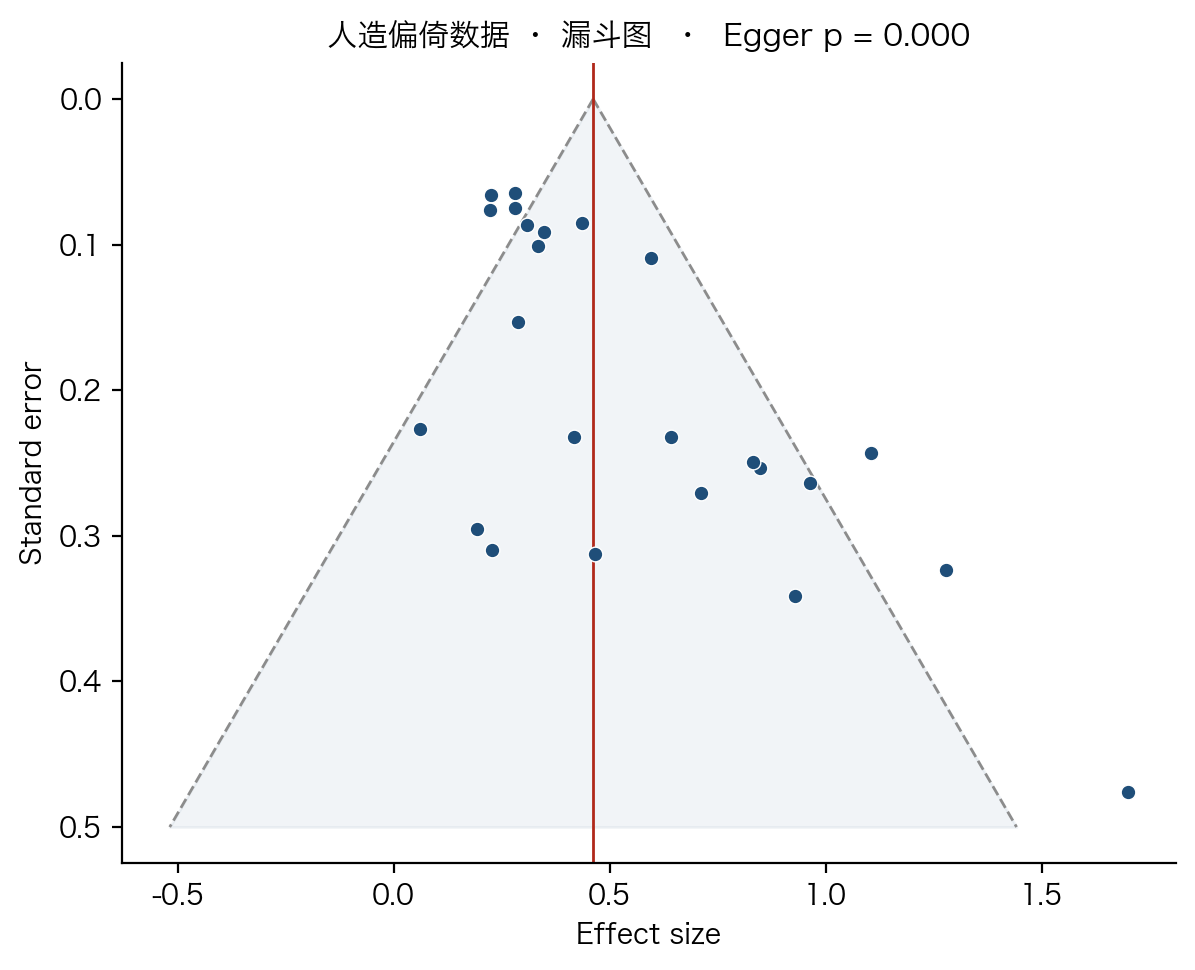

In [6]:
sv.pl.funnel(study, out="fig25_funnel.png", title="人造偏倚数据 · 漏斗图")
Image("fig25_funnel.png")

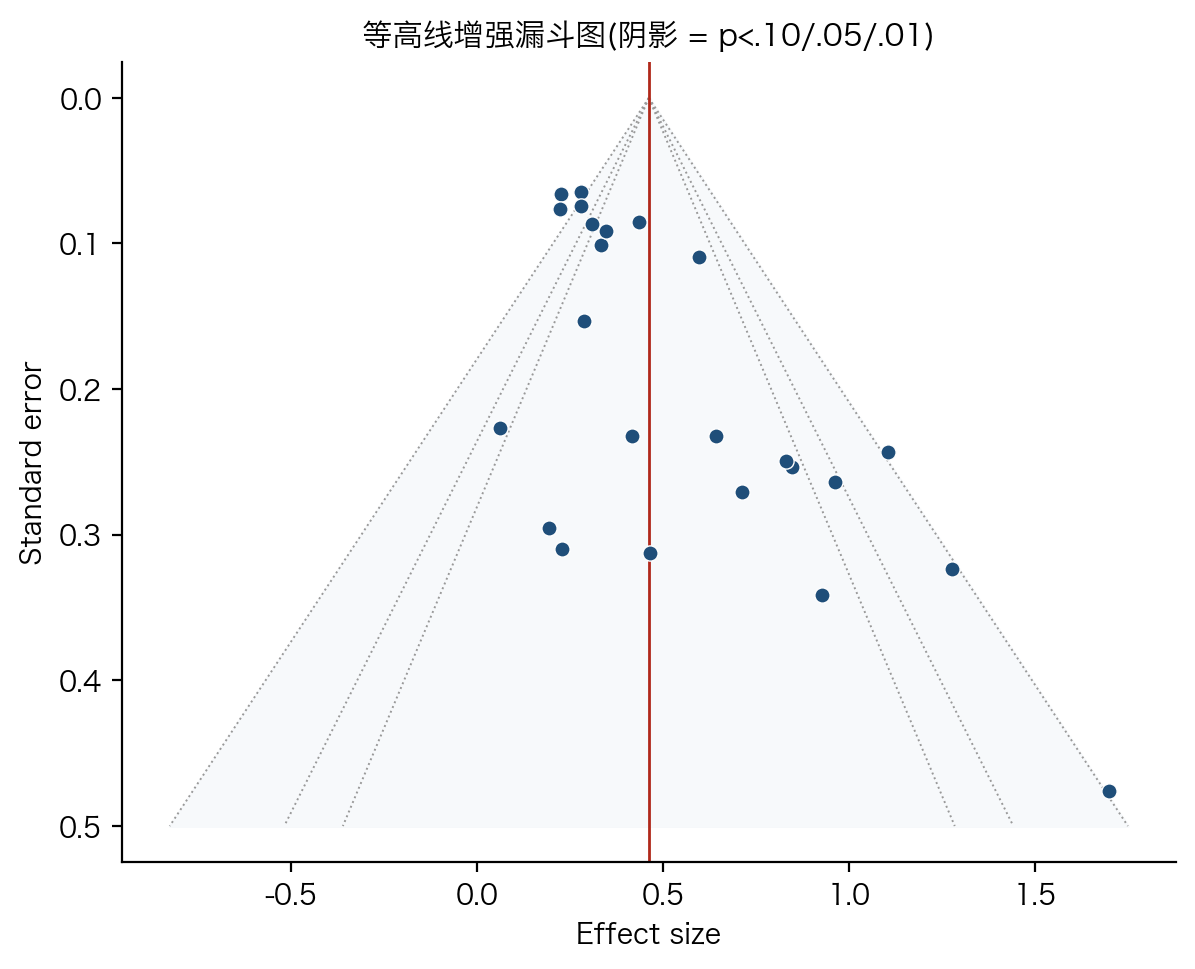

In [7]:
sv.pl.funnel_contour(study, out="fig25_funnel_contour.png",
                     title="等高线增强漏斗图(阴影 = p<.10/.05/.01)")
Image("fig25_funnel_contour.png")

## 5. 剪补法:估计缺了几篇,补回来估计会往哪走

**解决什么问题**:Duval-Tweedie **trim-and-fill** 不止检验不对称,还给一个可操作的校正:先「剪」
掉造成不对称的极端研究、重估中心,再在对侧「补」上镜像的假想研究(它们代表「没被发表的」那批),
用补全后的集合重估合并效应。输出 `k0_missing`(估计缺失研究数)和 `estimate_adjusted`(补全后估计)。

**关键前提**:重异质性下 trim-and-fill 会过校正或欠校正,它是**诊断而非可盲信的修正**——所以
我们把它和别的方法并列看,而不是单独下结论。

In [8]:
sv.tl.trim_and_fill(study)
tf = study.diagnostics["trim_and_fill"]
print(f"估计缺失研究数 k0 = {tf['k0_missing']}  (削掉的一侧:{tf['side']})")
print(f"观测合并   d = {tf['estimate_observed']:.3f}")
print(f"补全后     d = {tf['estimate_adjusted']:.3f}   (真值 {TRUE_D};向真值方向移动)")

估计缺失研究数 k0 = 3  (削掉的一侧:right)
观测合并   d = 0.353
补全后     d = 0.335   (真值 0.15;向真值方向移动)


## 6. 精度-效应回归:PET / PEESE / 条件 PET-PEESE

**解决什么问题**:如果小研究效应是线性的,可以**把效应对精度回归,再外推到「无限精度」**处
当作去偏效应。三件套:

- **PET**(precision-effect test):`yi ~ sei` 的加权回归,**截距**是精度趋于无穷(sei→0)时的效应;
  同时检验这个截距是否 ≠ 0(有没有真效应);
- **PEESE**:`yi ~ vi`(用方差而非标准误),曲率更贴合、截距偏差更小,**但只在确有真效应时才该用**;
- **条件 PET-PEESE**:先跑 PET,若其截距单侧显著(判定「有真效应」)则改用 PEESE 的截距,否则用
  PET 的截距。这是 Stanley-Doucouliagos 推荐的默认流程。

**关键前提**:PET-PEESE 在 p-hacking 下会**向下偏**,应与未校正估计并列汇报。

In [9]:
sv.tl.pet(study)
sv.tl.peese(study)
sv.tl.pet_peese(study)
pet = study.diagnostics["pet"]
peese = study.diagnostics["peese"]
pp = study.diagnostics["pet_peese"]
print(f"PET   截距(去偏效应) = {pet['intercept']:.3f}  (SE {pet['intercept_se']:.3f}, 斜率 {pet['slope']:.3f})")
print(f"PEESE 截距(去偏效应) = {peese['intercept']:.3f}  (SE {peese['intercept_se']:.3f})")
print(f"条件 PET-PEESE → 采用 {pp['model']},去偏后 d = {pp['corrected_estimate']:.3f}  (真值 {TRUE_D})")

PET   截距(去偏效应) = 0.138  (SE 0.057, 斜率 2.082)
PEESE 截距(去偏效应) = 0.271  (SE 0.036)
条件 PET-PEESE → 采用 PEESE,去偏后 d = 0.271  (真值 0.15)


## 7. 选择模型:显式给「发表概率」建模

**解决什么问题**:前面的方法都是「看不对称、事后校正」;**Vevea-Hedges 阶梯函数选择模型**换个
思路——**直接把发表过程写进似然**。它按 p 值区间(比如 p<.025 / .025–.05 / .05–.5 / >.5)各估
一个**发表权重** ω,同时估计去偏后的 μ 和 τ²;再用似然比检验(LRT)判「有没有选择」。

**关键前提**:权重按**单侧 p 值**的阶梯定义,`steps=` 给的是单侧 p 的切点。若显著区间的 ω 明显
大于不显著区间,就是「显著才发表」的直接证据。**哪几步**:传 `steps` → 读 `mu_adjusted`(去偏 μ)
/ `weights`(各区间发表权重)/ `lrt_pval`(选择是否显著)。

In [10]:
sv.tl.selection_model_stepfun(study, steps=[0.025, 0.05, 0.5])
sm = study.models["selection_model"]
print(f"未校正 μ   = {sm['mu_unadjusted']:.3f}")
print(f"选择校正 μ = {sm['mu_adjusted']:.3f}   (真值 {TRUE_D})")
print(f"τ²         = {sm['tau2']:.4f}")
print(f"发表权重 ω(按单侧 p 区间 {sm['steps']}): "
      + ", ".join(f"{w:.2f}" for w in sm["weights"]))
print(f"选择 LRT   p = {sm['lrt_pval']:.4f}  →  {'存在选择性发表' if sm['lrt_pval'] < 0.05 else '未检出选择'}"
      f"  (收敛: {sm['converged']})")

未校正 μ   = 0.353
选择校正 μ = 0.108   (真值 0.15)
τ²         = 0.1248
发表权重 ω(按单侧 p 区间 [0.025, 0.05, 0.5, 1.0]): 1.00, 0.56, 0.16, 0.00
选择 LRT   p = 0.0238  →  存在选择性发表  (收敛: True)


## 8. 只用显著研究判证据价值:p-curve / p-uniform / p-uniform*

**解决什么问题**:另一条独立思路——**只看显著研究的 p 值分布形状**。若真有效应,显著 p 值会
**右偏**(挤向 0);若是纯噪声 + 选择性报告,分布会更平甚至左偏。

- **p-curve**:检验显著研究的 p 值是否右偏(`Z < −1.645` ⇒ 有证据价值);
- **p-uniform**:要求「条件 p 值」在真效应处均匀,反推去偏效应估计 + 发表偏倚检验;
- **p-uniform\***(实验性):联合估计 μ 与 τ²,用上全部(含不显著)研究,比 p-uniform 更稳但
  求解更娇气。

**关键前提**:这些方法只用显著研究,**功效吃 k 和效应大小**;p-uniform 的 brentq 求根在某些
数据形状(如本例大量高度显著的大研究)下可能**无法定界而返回 NaN**——这是方法的真实局限,
我们如实展示,并用 p-uniform\* 兜底。

In [11]:
sv.tl.pcurve(study)
sv.tl.puniform(study)
sv.tl.puniform_star(study)
pc = study.diagnostics["pcurve"]
pu = study.diagnostics["puniform"]
pus = study.diagnostics["puniform_star"]
print(f"p-curve   : 显著研究 {pc['k_significant']} 项,右偏 Z = {pc['Z_right_skew']:.2f}"
      f"  →  {'有证据价值(右偏)' if pc['evidential_value'] else '偏平,证据价值存疑'}")
print(f"p-uniform : 去偏效应 = {pu['effect_puniform']}"
      f"  (朴素 {pu['effect_naive']:.3f};NaN = brentq 无法定界,本数据形状下的已知局限)")
print(f"p-uniform*: 去偏效应 = {pus['effect']:.3f},τ² = {pus['tau2']:.4f}  (收敛 {pus['converged']})")

p-curve   : 显著研究 18 项,右偏 Z = -10.75  →  有证据价值(右偏)
p-uniform : 去偏效应 = nan  (朴素 0.353;NaN = brentq 无法定界,本数据形状下的已知局限)
p-uniform*: 去偏效应 = 0.367,τ² = 0.0291  (收敛 True)


/Users/fernandozeng/Desktop/analysis/omicos-project/socialverse/socialverse/tl/_meta_selection.py:135: RuntimeWarning: invalid value encountered in divide
  q = stats.norm.sf((ys - mu) / ss) / stats.norm.sf((ycrit - mu) / ss)


## 9. 失安全数 + 过度显著检验(辅助证据)

**解决什么问题**:两个传统但**已不建议作主要证据**的辅助量:

- **失安全数(fail-safe N)**:Rosenthal 版问「还要多少篇零效应研究才能把总结果推翻到不显著」,
  Orwin 版问「多少篇才能把效应降到平凡阈值」。数字大 = 结论看似稳,但它对偏倚方向不敏感,
  Becker(2005)已建议弃用为主指标。
- **过度显著检验(TES,Ioannidis-Trikalinos)**:比较**观测到的显著研究数** vs 按合并效应和各研究
  功效算出的**期望显著数**。观测 > 期望暗示「显著结果过多」——可能是选择性发表。

**关键前提**:两者在异质性下都会膨胀第一类错误,只当**佐证**,不单独定案。

In [12]:
sv.tl.failsafe_n(study)
sv.tl.excess_significance(study)
fs = study.diagnostics["failsafe_n"]
xs = study.diagnostics["excess_significance"]
print(f"失安全数   Rosenthal = {fs['rosenthal']:.0f},Orwin = {fs['orwin']:.0f}  (仅辅助)")
print(f"过度显著   观测显著 {xs['observed_sig']} vs 期望 {xs['expected_sig']:.1f}"
      f"  (χ² = {xs['chi2']:.2f}, p = {xs['pval']:.3f})  →  {'显著数偏多' if xs['excess'] else '未见过度显著'}")

失安全数   Rosenthal = 1953,Orwin = 61  (仅辅助)
过度显著   观测显著 18 vs 期望 15.3  (χ² = 1.31, p = 0.252)  →  显著数偏多


## 10. S 值敏感性 + 一表汇总

**解决什么问题**:与其纠结「有没有偏倚」,Mathur-VanderWeele **选择敏感性**换个问法——
**「肯定性(显著且正向)研究被多超额发表(倍率 η),才会把结论推翻到阈值?」** 这个临界 η
就是 **S 值**。S 值很大 = 结论对选择很稳健;若在 η 很大时效应仍未跌破阈值,则记为「robust」。

最后 `pubbias_report` 把 Egger / 剪补 / PET-PEESE / 选择模型 / 敏感性**汇到一张表**,给一个整体
concern 等级(low/some/moderate/high)。**哪几步**:`pubbias_sensitivity` 给校正曲线与 S 值 →
`pubbias_report` 汇总。

In [13]:
sv.tl.pubbias_sensitivity(study, threshold=0.0)
sens = study.diagnostics["pubbias_sensitivity"]
print("选择敏感性 · 校正曲线(η = 肯定性研究超额发表倍率):")
for eta, val in sens["correction_curve"].items():
    print(f"   η = {eta:>2}×  →  校正后 d = {val:.3f}")
print(f"S 值(推翻到阈值 {sens['threshold']} 所需 η)= {sens['s_value_eta']}"
      f"  →  {'即便 η 很大效应仍在,稳健' if sens['robust_to_selection'] else '较易被选择推翻'}")

选择敏感性 · 校正曲线(η = 肯定性研究超额发表倍率):
   η =  1×  →  校正后 d = 0.353
   η =  2×  →  校正后 d = 0.347
   η =  3×  →  校正后 d = 0.343
   η =  5×  →  校正后 d = 0.335
   η = 10×  →  校正后 d = 0.321
S 值(推翻到阈值 0.0 所需 η)= None  →  即便 η 很大效应仍在,稳健


In [14]:
sv.tl.pubbias_report(study)
rep = study.diagnostics["pubbias_report"]
print("== 发表偏倚一览 ==")
print(f"  Egger p            : {rep['egger_pval']:.4f}")
print(f"  剪补 k0 / 校正后    : {rep['trimfill_k0']}  /  d = {rep['trimfill_adjusted']:.3f}")
print(f"  PET-PEESE 校正后    : d = {rep['petpeese_corrected']:.3f}")
print(f"  选择模型 校正 μ / p : {rep['selection_adjusted_mu']:.3f}  /  p = {rep['selection_lrt_pval']:.4f}")
print(f"  敏感性 S 值         : {rep['sensitivity_svalue']}")
print(f"  → 整体 concern 等级 : {rep['concern_level'].upper()}")

== 发表偏倚一览 ==
  Egger p            : 0.0002
  剪补 k0 / 校正后    : 3  /  d = 0.335
  PET-PEESE 校正后    : d = 0.271
  选择模型 校正 μ / p : 0.108  /  p = 0.0238
  敏感性 S 值         : None
  → 整体 concern 等级 : HIGH


## 11. 影响诊断(上):留一 + 累积

**解决什么问题**:发表偏倚之外,还要问**结论是不是被一两篇在驱动**。

- **留一(leave-one-out)**:每次剔掉一篇重估合并,看合并效应/CI/τ²/I² 的轨迹。某篇一去掉结论
  就翻,说明结论脆弱。
- **累积 meta(cumulative)**:按年份(或精度)排序,每加入一篇看合并估计如何积累、何时稳定。
  按年份排序时,若早期小研究把估计顶得很高、后来大研究把它拉下来,正是小研究效应的时间指纹。

In [15]:
sv.tl.leave_one_out(study, method="REML")
loo = pd.DataFrame(study.diagnostics["leave_one_out"]["rows"])
print("留一敏感性(剔掉后合并 d 的范围):"
      f" [{loo['estimate'].min():.3f}, {loo['estimate'].max():.3f}]  —— 无单篇能翻转结论")
loo_show = loo.reindex(loo["estimate"].abs().sort_values(ascending=False).index).head(4)
print(loo_show[["omitted", "estimate", "ci_lb", "ci_ub", "I2"]].round(3).to_string(index=False))

留一敏感性(剔掉后合并 d 的范围): [0.416, 0.481]  —— 无单篇能翻转结论
omitted  estimate  ci_lb  ci_ub     I2
    S16     0.481  0.366  0.596 70.979
    S17     0.481  0.363  0.599 72.576
    S19     0.481  0.366  0.596 71.859
    S18     0.481  0.363  0.599 73.378


In [16]:
sv.tl.cumulative_ma(study, order="year", method="REML")
cum = pd.DataFrame(study.diagnostics["cumulative_ma"]["rows"])
print(f"累积 meta(按 {study.diagnostics['cumulative_ma']['ordered_by']} 排序)首尾对比:")
print(f"   加入第 1 项后  d = {cum.iloc[0]['estimate']:.3f}")
print(f"   全部加入后    d = {cum.iloc[-1]['estimate']:.3f}")
cum[["added", "k", "estimate", "ci_lb", "ci_ub"]].round(3).head(6)

累积 meta(按 year 排序)首尾对比:
   加入第 1 项后  d = 1.278
   全部加入后    d = 0.462


,added,k,estimate,ci_lb,ci_ub
0,S1,1,1.278,0.644,1.912
1,S2,2,0.648,-0.543,1.839
2,S3,3,0.795,0.040,1.550
3,S4,4,0.712,0.148,1.277
4,S5,5,0.646,0.200,1.092
5,S6,6,0.678,0.307,1.048


## 12. 影响诊断(下):逐研究 influence + 剔离群重估

**解决什么问题**:把「谁在驱动」量化到每一篇。`influence` 给每项研究一组 metafor 风格诊断——
**学生化删除残差**(离群?)、**DFFITS**(去掉它合并估计动多少)、**Cook's D**(综合影响)、
**杠杆/权重**、**τ²-deleted**——并按阈值标注「影响点」。`outlier_refit` 则把被标注的离群研究
剔掉后重估,报告合并效应的**位移 delta**:位移小 = 结论稳健。

In [17]:
sv.tl.influence(study, method="REML")
inf = study.diagnostics["influence"]
infd = pd.DataFrame(inf["rows"])
print(f"影响诊断:{inf['n_influential']} 项被标为影响点"
      f"  (DFFITS 阈值 {inf['dffits_cutoff']:.2f},杠杆阈值 {inf['hat_cutoff']:.3f})")
top = infd.reindex(infd["cooks_d"].sort_values(ascending=False).index).head(5)
print(top[["study", "rstudent", "dffits", "cooks_d", "weight_pct", "influential"]].round(3).to_string(index=False))

影响诊断:3 项被标为影响点  (DFFITS 阈值 0.61,杠杆阈值 0.125)
study  rstudent  dffits  cooks_d  weight_pct  influential
   S3     2.422   0.991    0.678       3.112         True
   S1     2.342   0.691    0.373       2.137         True
   S9     1.653   0.488    0.206       2.813        False
  S12     2.488   0.494    0.206       1.162         True
  S16    -1.178  -0.331    0.121       6.883        False


In [18]:
sv.tl.outlier_refit(study, method="REML")
orf = study.diagnostics["outlier_refit"]
print(f"剔除离群 {orf['n_removed']} 项后重估:")
print(f"   全量   d = {orf['estimate_full']:.3f}  (I² = {orf['I2_full']:.1f}%)")
print(f"   剔离群 d = {orf['estimate_trimmed']:.3f}  (I² = {orf['I2_trimmed']:.1f}%)")
print(f"   位移 delta = {orf['delta']:+.3f}  →  {'剔除离群后向真值靠拢' if abs(orf['delta'])>0.01 else '几乎不变,稳健'}")

剔除离群 3 项后重估:
   全量   d = 0.462  (I² = 72.4%)
   剔离群 d = 0.368  (I² = 39.3%)
   位移 delta = -0.094  →  剔除离群后向真值靠拢


## 13. Baujat + GOSH:异质性来自哪、结论有没有多峰

**解决什么问题**:两张诊断图收束「结构性」问题。

- **Baujat 图**:横轴 = 各研究对总异质性 Q 的贡献,纵轴 = 对合并估计的影响。**右上角**的点既制造
  异质又左右结论——最该复核的研究。
- **GOSH 图**(graphical display of study heterogeneity):对**大量随机研究子集**各算一次合并效应与
  I²,画成云。**单峰**云 = 结论稳健;**多峰/离群簇** = 存在把结果拉向不同方向的子群,合并的
  「平均」掩盖了结构。

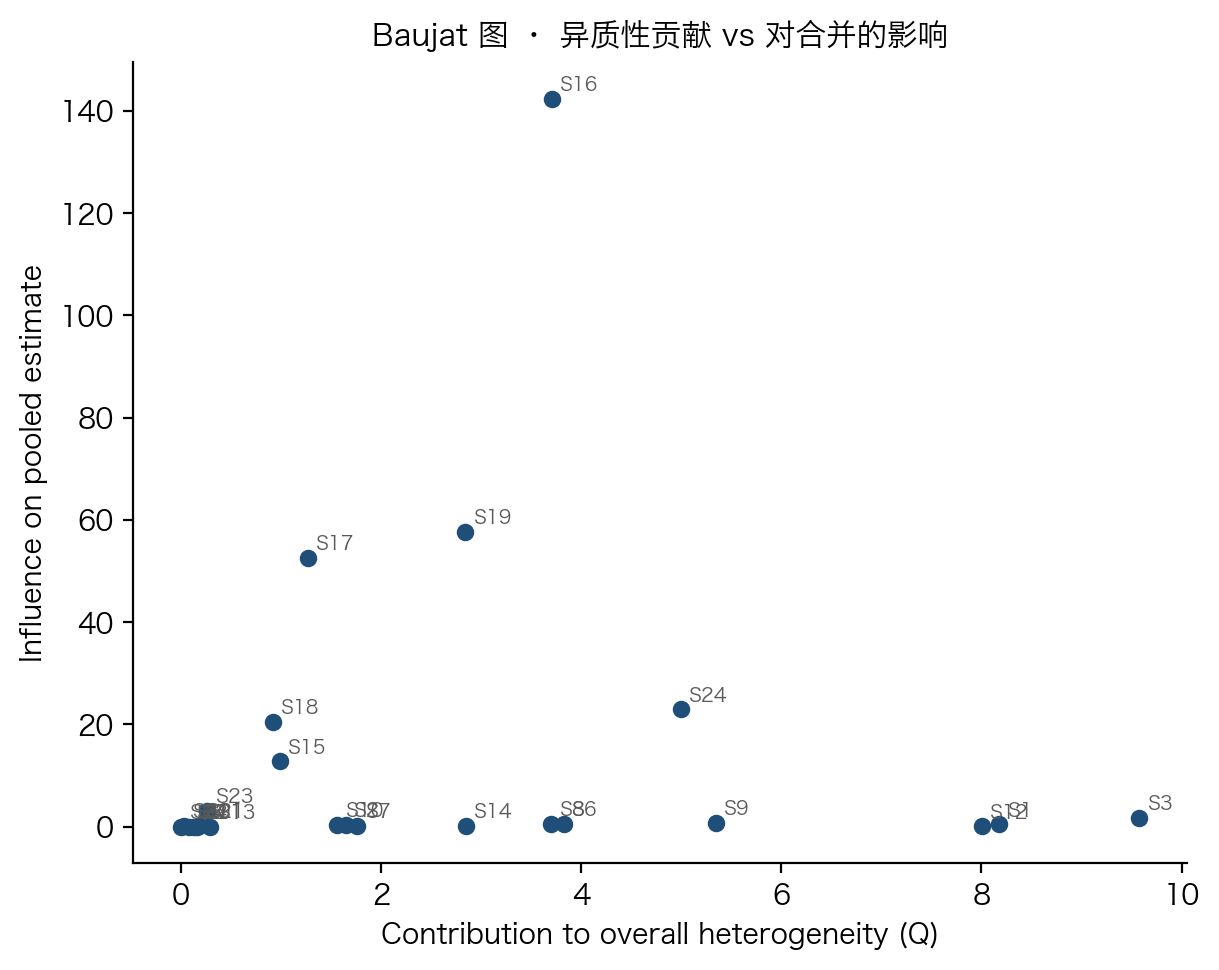

In [19]:
sv.pl.baujat(study, out="fig25_baujat.png",
             title="Baujat 图 · 异质性贡献 vs 对合并的影响")
Image("fig25_baujat.png")

/Users/fernandozeng/Desktop/analysis/omicos-project/socialverse/socialverse/pl/_figure.py:136: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) Hiragino Sans GB.
  fig.savefig(path, dpi=_DPI, bbox_inches="tight")


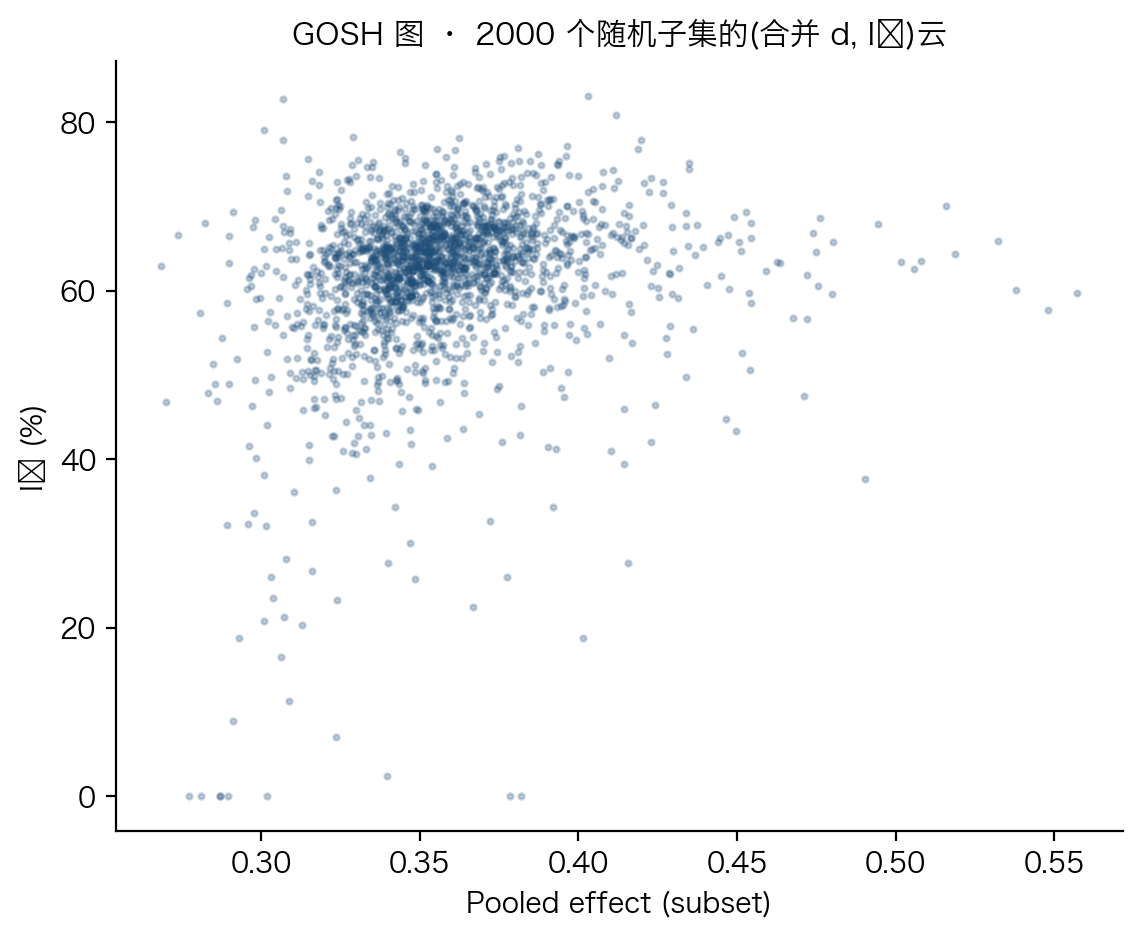

In [20]:
sv.pl.gosh(study, out="fig25_gosh.png", nsub=2000, seed=2025,
           title="GOSH 图 · 2000 个随机子集的(合并 d, I²)云")
Image("fig25_gosh.png")

## 小结:一条把「被夸大的结论」挤回真值的证据链

我们用一份**已知真值 d = 0.15、但被小研究效应夸大到 ~0.35** 的数据,走完了整套发表偏倚 +
稳健性诊断。每个数字都能追到是哪个 `sv.*` 函数、从同一份 `meta_effects` 算出的:

```
合成偏倚数据 ──sv.pp.escalc(SMD)──▶ meta_effects(yi, vi)
            ──sv.tl.meta_random──▶ 朴素合并 d ≈ 0.35(真值 0.15,被夸大 ~2.4×)
  不对称检验 ──egger_test / begg_test / sv.pl.funnel_contour──▶ Egger p<.001,漏斗左侧被削
  事后校正   ──trim_and_fill / pet·peese·pet_peese──▶ 校正后 d 向 0.15 回落
  选择建模   ──selection_model_stepfun──▶ 显著区间发表权重↑,校正 μ 明显下移,LRT 显著
  证据价值   ──pcurve / puniform / puniform_star──▶ p-curve 右偏(有真效应),p-uniform* 兜底估计
  辅助佐证   ──failsafe_n / excess_significance──▶ 观测显著数偏多
  敏感性     ──pubbias_sensitivity / pubbias_report──▶ S 值 + 一表汇总,concern = HIGH
  影响诊断   ──leave_one_out / cumulative_ma / influence / outlier_refit / baujat / gosh
             ──▶ 无单篇能翻转结论,但小研究整体在系统性顶高估计
```

**要点**:(1) 发表偏倚是**系统性夸大**,不是随机噪声,必须专门诊断;(2) 没有单一「正确」的
校正——Egger 看不对称、trim-fill/PET-PEESE 事后拉回、选择模型显式建模、p-uniform 只用显著研究、
S 值量化稳健性,**方法互补、结论要看它们是否一致**;(3) 影响诊断确认结论不是被少数研究绑架;
(4) 这份数据里,五路校正一致地把 0.35 挤回 0.15 附近、`pubbias_report` 判 HIGH——这才是一个
**经得起推敲**的诚实结论。

至此,meta 分析系列从入门([22 · Meta 分析入门](22_meta_analysis_basics.ipynb))、多层与稳健
([23 · 多层与稳健 meta](23_multilevel_and_robust_meta.ipynb))到本篇的偏倚与稳健性,已覆盖
单一 meta 的完整工作流。下一步是把「多个处理互相比较」的**网络 meta 分析(netmeta)** 接上——
那时漏斗对称性要在**对比层**重看,而一致性(consistency)成为新的稳健性前提。